In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


In [2]:
df = pd.read_csv('datasets/confuse_matrix.csv')
df.head()

,Feature_1,Feature_2,Target
0,1.101034,2.035353,1
1,1.255945,-1.672352,0
2,1.854479,-1.448528,0
3,3.603090,-0.266515,0
4,1.253178,1.287514,1


In [3]:
df = df.rename(columns={"Feature_1":"fa", "Feature_2":"fb", "Target":"tar"})
df.head()

,fa,fb,tar
0,1.101034,2.035353,1
1,1.255945,-1.672352,0
2,1.854479,-1.448528,0
3,3.603090,-0.266515,0
4,1.253178,1.287514,1


In [4]:
x = df.drop(columns=["tar"])
y = df["tar"]

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [7]:
# cheking accuracy
lr.score(x_test, y_test)*100

97.5

In [8]:
# checking overfitting
lr.score(x_train, y_train)*100

98.125

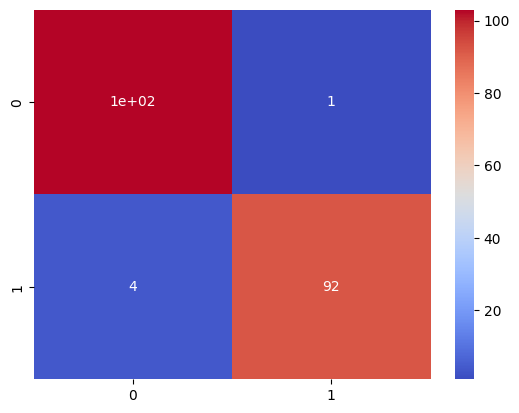

In [9]:
# confusion matrix
cf = confusion_matrix(y_test, lr.predict(x_test))
sns.heatmap(cf, annot=True, cmap="coolwarm")
plt.show()

In [10]:
ps = precision_score(y_test, lr.predict(x_test))*100
ps

98.9247311827957

In [11]:
rs = recall_score(y_test, lr.predict(x_test))*100
rs

95.83333333333334

In [12]:
fs = f1_score(y_test, lr.predict(x_test))*100
fs

97.35449735449735

In [13]:
df['tar'].value_counts()

tar
0    501
1    499
Name: count, dtype: int64

c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


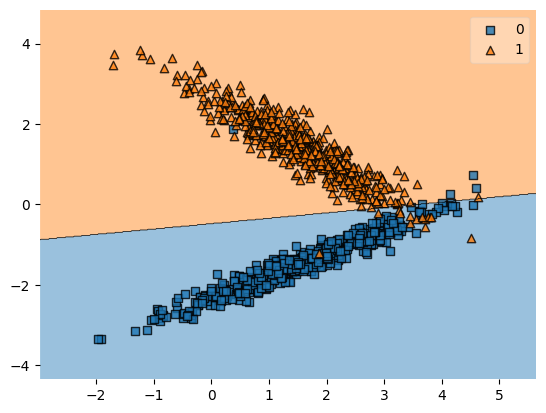

In [14]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf=lr)
plt.show()